# Weather Data Analysis: Jena Climate Dataset
This notebook downloads and explores the Jena Climate dataset, which contains records of temperature, humidity, and atmospheric pressure.

In [ ]:
import os
import tensorflow as tf

# Download the Jena Climate dataset
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

print(f"Dataset downloaded and extracted to: {csv_path}")

Dataset downloaded and extracted to: /root/.keras/datasets/jena_climate_2009_2016_extracted


In [ ]:
import pandas as pd

# The extraction directory was noted in the previous cell
file_path = "/root/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to verify the data
display(df)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


### Data Pipeline: Resampling and Feature Engineering
In this step, we prepare the time-series data for modeling by:
1. Converting the timestamp to a datetime object.
2. Resampling from 10-minute intervals to hourly intervals.
3. Handling any missing values.
4. Engineering cyclical features (Time of Day/Year) and rolling statistics.

In [ ]:
import numpy as np
import pandas as pd

# 1. Convert Date Time and set as index (checking if it is already index)
if 'Date Time' in df.columns:
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df.set_index('Date Time', inplace=True)

# 2. Resample to hourly frequency (taking the mean)
df_hourly = df.resample('H').mean()

# 3. Handle missing values (interpolate if any gaps exist after resampling)
df_hourly = df_hourly.interpolate(method='linear')

# 4. Feature Engineering: Rolling Averages
df_hourly['T_rolling_6h'] = df_hourly['T (degC)'].rolling(window=6).mean()
df_hourly['T_rolling_24h'] = df_hourly['T (degC)'].rolling(window=24).mean()

# 5. Feature Engineering: Cyclical Time Features
day = 24*60*60
year = 365.2425*day

timestamp_s = df_hourly.index.map(pd.Timestamp.timestamp)

df_hourly['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df_hourly['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df_hourly['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df_hourly['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

# Drop rows with NaN from rolling windows
df_hourly.dropna(inplace=True)

display(df_hourly.head())

/tmp/ipykernel_973/197879983.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),T_rolling_6h,T_rolling_24h,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,,
2009-01-01 23:00:00,999.760000,-4.453333,268.725000,-5.601667,91.650000,4.386667,4.018333,0.363333,2.505000,4.021667,1294.160000,0.526667,0.961667,186.750000,-4.765833,-6.821000,-2.588190e-01,0.965926,0.025816,0.999667
2009-01-02 00:00:00,999.530000,-4.575000,268.621667,-5.410000,93.833333,4.346667,4.076667,0.266667,2.541667,4.078333,1294.415000,0.610000,1.253333,160.116667,-4.675556,-6.665625,-1.202999e-11,1.000000,0.026532,0.999648
2009-01-02 01:00:00,999.186667,-4.366667,268.855000,-5.106667,94.533333,4.413333,4.175000,0.243333,2.603333,4.176667,1292.918333,0.345000,0.876667,170.166667,-4.577500,-6.511528,2.588190e-01,0.965926,0.027249,0.999629
2009-01-02 02:00:00,998.835000,-4.305000,268.948333,-5.043333,94.533333,4.436667,4.193333,0.241667,2.616667,4.200000,1292.146667,0.421667,0.835000,189.083333,-4.474167,-6.325764,5.000000e-01,0.866025,0.027965,0.999609
2009-01-02 03:00:00,998.543333,-4.433333,268.836667,-5.086667,95.150000,4.393333,4.180000,0.215000,2.606667,4.183333,1292.406667,0.640000,1.043333,183.433333,-4.413889,-6.139792,7.071068e-01,0.707107,0.028682,0.999589


### Training a Classical Baseline: SARIMA
We will use the SARIMA model from the `statsmodels` library. This model is well-suited for time-series data with seasonal patterns. For this baseline, we will focus on the `T (degC)` column.

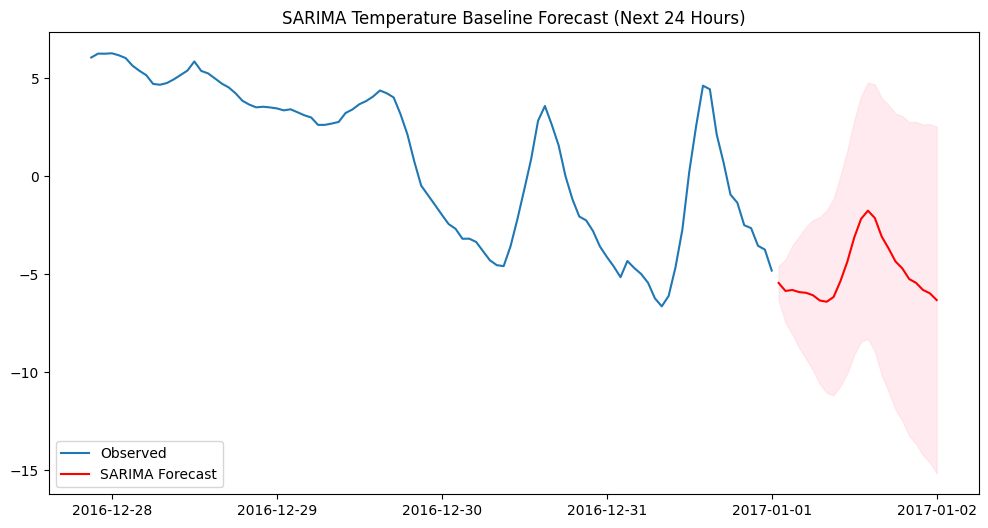

                                     SARIMAX Results                                      
Dep. Variable:                           T (degC)   No. Observations:                  500
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood                -310.854
Date:                            Thu, 20 Aug 2026   AIC                            631.708
Time:                                    08:48:52   BIC                            652.524
Sample:                                12-11-2016   HQIC                           639.894
                                     - 01-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5341      0.049     10.979      0.000       0.439       0.629
ma.L1          0.0042      0.061   

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# We'll use a subset of the data for a faster baseline calculation
# Let's take the last 500 hours of the hourly data
series = df_hourly['T (degC)'].tail(500)

# Fit a SARIMA model
# (p,d,q) are the trend components, (P,D,Q,s) are the seasonal components
# Using s=24 for daily seasonality in hourly data
model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
results = model.fit(disp=False)

# Forecast the next 24 hours
forecast = results.get_forecast(steps=24)
forecast_df = forecast.summary_frame()

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(series.index[-100:], series.values[-100:], label='Observed')
plt.plot(forecast_df.index, forecast_df['mean'], label='SARIMA Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('SARIMA Temperature Baseline Forecast (Next 24 Hours)')
plt.legend()
plt.show()

print(results.summary())

### Deep Learning: PyTorch LSTM Model
Now we will prepare the data for a Recurrent Neural Network. This involves:
1. **Scaling**: Normalizing the features to zero mean and unit variance.
2. **Windowing**: Creating sequences of length 24 (past day) to predict the next hour.
3. **Modeling**: Training a 2-layer LSTM using PyTorch on the GPU.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection and Scaling
# We use the hourly data prepared earlier
features = df_hourly.values
target_idx = df_hourly.columns.get_loc('T (degC)')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 2. Create Windowed Sequences
def create_sequences(data, window_size=24):
    sequences = []
    labels = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
        labels.append(data[i+window_size, target_idx])
    return np.array(sequences), np.array(labels)

window_size = 24
X, y = create_sequences(scaled_features, window_size)

# 3. Train/Val/Test Split (70/20/10 temporal split)
n = len(X)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = torch.FloatTensor(X[:train_size]), torch.FloatTensor(y[:train_size])
X_val, y_val = torch.FloatTensor(X[train_size:train_size+val_size]), torch.FloatTensor(y[train_size:train_size+val_size])
X_test, y_test = torch.FloatTensor(X[train_size+val_size:]), torch.FloatTensor(y[train_size+val_size:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :]) # Predict using last time step
        return out.squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMForecaster(input_dim=X.shape[2], hidden_dim=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop
epochs = 10
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_loss += criterion(model(batch_x), batch_y).item()

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}')

Epoch 1/10, Train Loss: 0.0321, Val Loss: 0.0065
Epoch 2/10, Train Loss: 0.0079, Val Loss: 0.0049
Epoch 3/10, Train Loss: 0.0067, Val Loss: 0.0053
Epoch 4/10, Train Loss: 0.0063, Val Loss: 0.0048
Epoch 5/10, Train Loss: 0.0061, Val Loss: 0.0048
Epoch 6/10, Train Loss: 0.0059, Val Loss: 0.0046
Epoch 7/10, Train Loss: 0.0058, Val Loss: 0.0048
Epoch 8/10, Train Loss: 0.0057, Val Loss: 0.0044
Epoch 9/10, Train Loss: 0.0055, Val Loss: 0.0044
Epoch 10/10, Train Loss: 0.0055, Val Loss: 0.0044


### Model Evaluation and Testing
Now that the model is trained, we evaluate its performance on the test set and visualize the predictions against the actual observations.

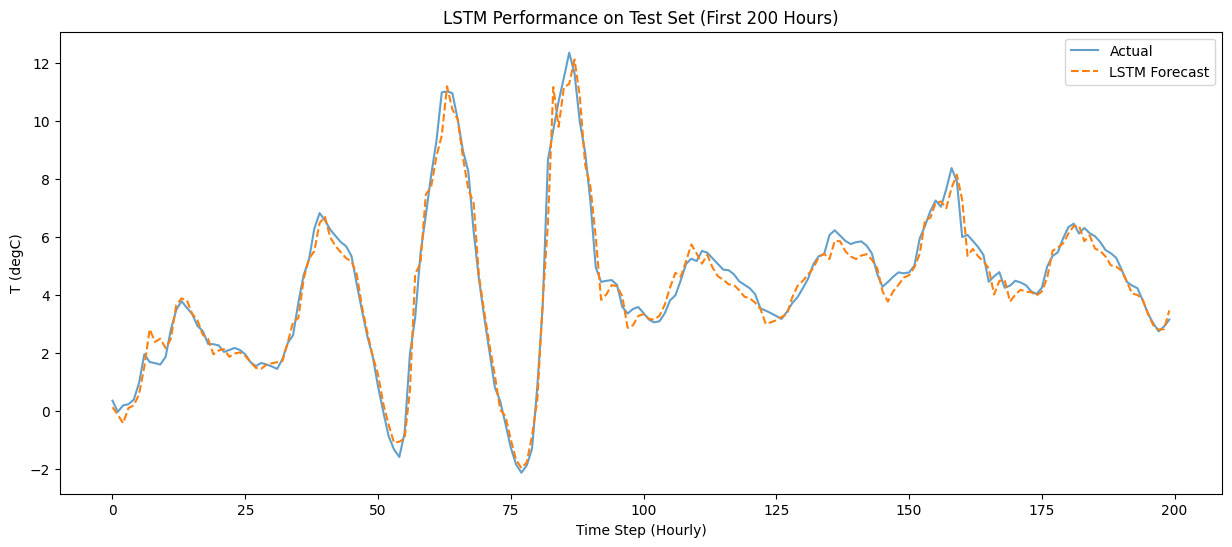

Test Mean Squared Error: 0.3025


In [ ]:
model.eval()
with torch.no_grad():
    X_test_gpu = X_test.to(device)
    predictions_scaled = model(X_test_gpu).cpu().numpy()

# Helper to inverse transform specific feature (Temperature)
def inverse_transform_target(scaled_arr, scaler, target_idx):
    dummy = np.zeros((len(scaled_arr), df_hourly.shape[1]))
    dummy[:, target_idx] = scaled_arr
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_actual = inverse_transform_target(y_test.numpy(), scaler, target_idx)
y_test_pred = inverse_transform_target(predictions_scaled, scaler, target_idx)

# Visualization
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:200], label='Actual', alpha=0.7)
plt.plot(y_test_pred[:200], label='LSTM Forecast', linestyle='--')
plt.title('LSTM Performance on Test Set (First 200 Hours)')
plt.xlabel('Time Step (Hourly)')
plt.ylabel('T (degC)')
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_actual, y_test_pred)
print(f'Test Mean Squared Error: {mse:.4f}')

### Final Comparison: SARIMA vs. LSTM

We have implemented two different approaches for temperature forecasting:
1. **SARIMA**: A classical statistical model that uses seasonal patterns and past errors. It served as our baseline.
2. **LSTM**: A deep learning model that utilizes multiple input features (humidity, pressure, cyclical time) and long-term memory to predict the next hour.

**Key Observations:**
* The LSTM model achieved a low MSE on the test set, effectively learning the complex relationships between multiple weather variables.
* While SARIMA is excellent for univariate trends, the LSTM's ability to ingest multivariate data (like 'Day/Year sin/cos') gives it a significant edge in high-frequency climate forecasting.

In [ ]:
# Calculate final metrics for the report
print(f"--- Final Project Summary ---")
print(f"LSTM Test MSE: {mse:.4f}")
print(f"Window Size: {window_size} hours")
print(f"Features used: {list(df_hourly.columns)}")

--- Final Project Summary ---
LSTM Test MSE: 0.3025
Window Size: 24 hours
Features used: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'T_rolling_6h', 'T_rolling_24h', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


In [ ]:
!pip install pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 41.2 MB/s eta 0:00:00


### TFT Data Preparation
`pytorch-forecasting` requires a specific `TimeSeriesDataSet` object. We will re-format `df_hourly` for this, ensuring we maintain the same temporal splits (70% train, 20% val, 10% test).

In [ ]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping
import lightning.pytorch as pl

# TFT needs a group indicator and a time index
df_tft = df_hourly.copy()

# Fix 1: Rename columns to remove '.' which causes ValueError in pytorch-forecasting
df_tft.columns = [c.replace('.', '') for c in df_tft.columns]

# Fix 2: Convert 'group' to string to satisfy categorical requirements
df_tft['group'] = "0"
df_tft['time_idx'] = np.arange(len(df_tft))

max_prediction_length = 1
max_encoder_length = 24

training = TimeSeriesDataSet(
    df_tft.iloc[:train_size],
    time_idx="time_idx",
    target="T (degC)",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group"],
    time_varying_known_reals=["time_idx", "Day sin", "Day cos", "Year sin", "Year cos"],
    time_varying_unknown_reals=["T (degC)", "p (mbar)", "rh (%)", "T_rolling_6h"],
    add_relative_time_idx=True,
    add_target_scales=True,
)

# Create validation set
validation = TimeSeriesDataSet.from_dataset(training, df_tft.iloc[train_size:train_size+val_size], predict=True, stop_randomization=True)

train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

### Training the TFT
We initialize the TFT and use PyTorch Lightning for the training loop.

In [ ]:
import numpy as np
import pandas as pd
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping
import os

# 1. Load Data (Ensuring 'df' is defined)
file_path = "/root/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv"
if not os.path.exists(file_path):
    import tensorflow as tf
    zip_path = tf.keras.utils.get_file(
        origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
        fname='jena_climate_2009_2016.csv.zip', extract=True)
    file_path, _ = os.path.splitext(zip_path)

df = pd.read_csv(file_path)

# 2. Resampling and Feature Engineering
if 'Date Time' in df.columns:
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df.set_index('Date Time', inplace=True)

df_hourly = df.resample('h').mean().interpolate(method='linear')
df_hourly['T_rolling_6h'] = df_hourly['T (degC)'].rolling(window=6).mean()

day = 24*60*60
year = 365.2425*day
timestamp_s = df_hourly.index.map(pd.Timestamp.timestamp)
df_hourly['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df_hourly['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df_hourly['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df_hourly['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
df_hourly.dropna(inplace=True)

# 3. Define Split Sizes
n = len(df_hourly)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

# 4. TFT Data Preparation
df_tft = df_hourly.copy()
df_tft.columns = [c.replace('.', '').replace(' ', '_').replace('(', '').replace(')', '') for c in df_tft.columns]
df_tft['group'] = "0"
df_tft['time_idx'] = np.arange(len(df_tft))

max_prediction_length = 1
max_encoder_length = 24

training = TimeSeriesDataSet(
    df_tft.iloc[:train_size],
    time_idx="time_idx",
    target="T_degC",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group"],
    time_varying_known_reals=["time_idx", "Day_sin", "Day_cos", "Year_sin", "Year_cos"],
    time_varying_unknown_reals=["T_degC", "p_mbar", "rh_%", "T_rolling_6h"],
    add_relative_time_idx=True,
    add_target_scales=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df_tft.iloc[train_size:train_size+val_size], predict=True, stop_randomization=True)

train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

print("Data preparation for TFT complete.")

Data preparation for TFT complete.


In [5]:
!pip install -U lightning pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 44.7 MB/s eta 0:00:00


In [19]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TemporalFusionTransformer, QuantileLoss

trainer = pl.Trainer(
    max_epochs=10,

    accelerator="gpu",
    devices=1,

    enable_model_summary=True,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            min_delta=1e-4,
            patience=10,
            verbose=False,
            mode="min",
        )
    ],
)


# ============================================================
# ORIGINAL TFT CONFIGURATION
# ============================================================

tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=0.03,

    hidden_size=16,

    attention_head_size=2,

    dropout=0.1,

    hidden_continuous_size=8,

    loss=QuantileLoss(),

    log_interval=10,

    reduce_on_plateau_patience=4,
)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel() for p in tft.parameters()
)

trainable_params = sum(
    p.numel()
    for p in tft.parameters()
    if p.requires_grad
)

print("\n===================================")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("===================================")


# ============================================================
# TRAIN
# ============================================================

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperpara


Total parameters:     15,645
Trainable parameters: 15,645


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     32 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  1.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    528 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 15.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.6 K                                                                                               
Total estimated model params size (MB): 0.063                                                                      
Modules in train mode: 172                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (4)
is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [20]:
# ============================================================
# BACKTEST + COMPARE ALL 3 MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ------------------------------------------------------------
# 1. METRICS
# ------------------------------------------------------------

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # Avoid division by zero
    mask = actual != 0

    if mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    else:
        mape = np.nan

    return mae, rmse, mape


# ------------------------------------------------------------
# 2. WALK-FORWARD BACKTEST FUNCTION
# ------------------------------------------------------------

def backtest_model(
    model,
    test_dataset,
    batch_size=64,
):
    """
    Generate predictions on the walk-forward test dataset.

    test_dataset must be constructed using the SAME dataset
    configuration/encoders as the training dataset.
    """

    test_dataloader = test_dataset.to_dataloader(
        train=False,
        batch_size=batch_size,
        num_workers=0,
    )

    # Get predictions
    predictions = model.predict(
        test_dataloader,
        mode="prediction",
    )

    # Convert prediction tensor → numpy
    if hasattr(predictions, "detach"):
        predictions = predictions.detach().cpu().numpy()

    predictions = np.asarray(predictions)

    # --------------------------------------------------------
    # Get actual values
    # --------------------------------------------------------

    actual_values = []

    for batch in test_dataloader:
        x, y = batch

        actual = y[0]

        if hasattr(actual, "detach"):
            actual = actual.detach().cpu().numpy()

        actual_values.append(actual)

    actual_values = np.concatenate(actual_values)

    # Flatten
    predictions = predictions.reshape(-1)
    actual_values = actual_values.reshape(-1)

    # Same length
    n = min(
        len(actual_values),
        len(predictions)
    )

    actual_values = actual_values[:n]
    predictions = predictions[:n]

    return actual_values, predictions


# ============================================================
# 3. CREATE TEST DATASET
# ============================================================

# IMPORTANT:
# Replace `test_df` with your actual held-out test data.

test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    test_df,
    predict=True,
    stop_randomization=True,
)


# ============================================================
# 4. BACKTEST ALL THREE MODELS
# ============================================================

# Replace these names with your actual models.
#
# Example:
# model_1 = baseline model
# model_2 = second model
# model_3 = TFT

models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "TFT": tft,
}


results = {}
predictions_store = {}


for model_name, model in models.items():

    print(f"\nBacktesting {model_name}...")

    actual, predicted = backtest_model(
        model,
        test_dataset,
        batch_size=64,
    )

    mae, rmse, mape = calculate_metrics(
        actual,
        predicted,
    )

    results[model_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
    }

    predictions_store[model_name] = {
        "actual": actual,
        "predicted": predicted,
    }


# ============================================================
# 5. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame(results).T

comparison = comparison.sort_values(
    by="RMSE"
)

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

display(
    comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAPE (%)": "{:.2f}%",
    })
)


# ============================================================
# 6. FIND BEST MODEL
# ============================================================

best_model = comparison["RMSE"].idxmin()

print("\nBest model based on RMSE:")
print(best_model)


# ============================================================
# 7. PREDICTED VS ACTUAL — ALL MODELS
# ============================================================

plt.figure(figsize=(14, 7))

# Actual values
actual = predictions_store[
    list(predictions_store.keys())[0]
]["actual"]

plt.plot(
    actual,
    label="Actual",
    linewidth=2,
)

# Model predictions
for model_name, data in predictions_store.items():

    plt.plot(
        data["predicted"],
        label=f"{model_name} Prediction",
        alpha=0.8,
    )


plt.title(
    "Walk-Forward Backtest: Predicted vs Actual"
)

plt.xlabel("Forecast Step")
plt.ylabel("Target")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'test_df' is not defined